In [124]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

In [125]:
def read_complex_binary(file_path):
    # Read the binary file
    with open(file_path, 'rb') as f:
        data = f.read()
    
    # Convert the binary data to a numpy array of complex doubles
    complex_data = np.frombuffer(data, dtype=np.complex128)
    return complex_data


In [126]:
file_path = '../build/samples.bin'


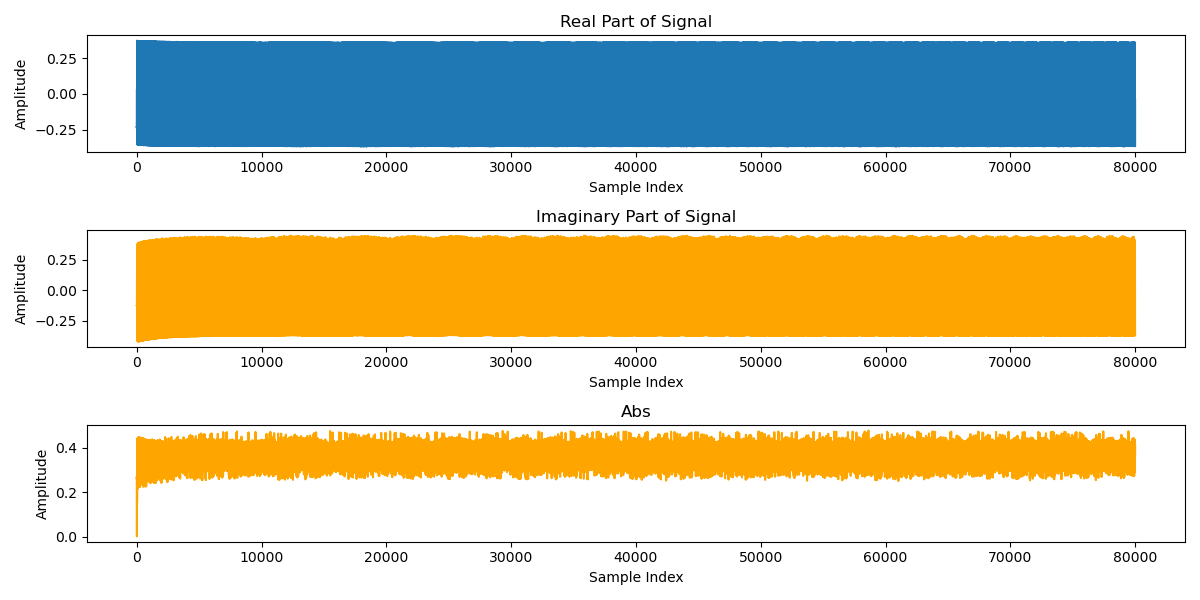

In [127]:
complex_data=read_complex_binary(file_path)

real_part = np.real(complex_data)
imaginary_part = np.imag(complex_data)

# Plot the real and imaginary parts
plt.figure(figsize=(12, 6))

plt.subplot(3, 1, 1)
plt.plot(real_part, label='Real Part')
plt.title('Real Part of Signal')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')

plt.subplot(3, 1, 2)
plt.plot(imaginary_part, label='Imaginary Part', color='orange')
plt.title('Imaginary Part of Signal')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')

plt.subplot(3, 1, 3)
plt.plot(np.sqrt(real_part**2+imaginary_part**2), label='Abs', color='orange')
plt.title('Abs')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')



plt.tight_layout()
plt.show()

## Frequency Domain


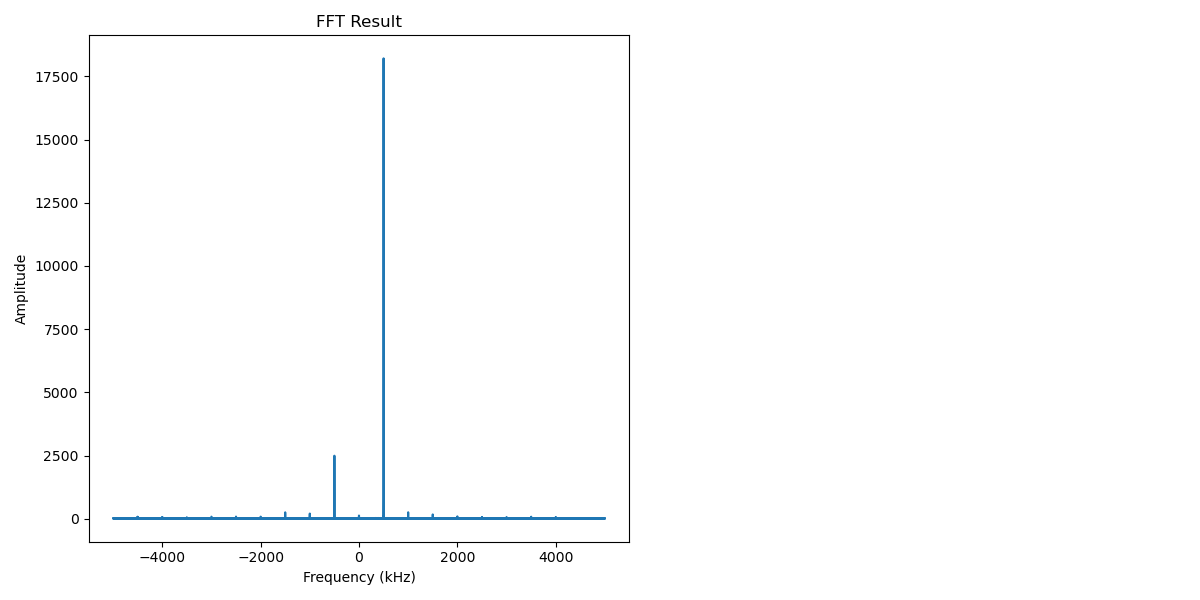

In [128]:
sampling_rate=10e6 #TX_RATE in config file
N=len(complex_data)
fft_result = np.fft.fft(complex_data)
freqs = np.fft.fftfreq(N, d=1/sampling_rate)
fft_flipped = np.fft.fftshift(fft_result)
freqs_flipped = np.fft.fftshift(freqs)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("FFT Result")
plt.plot(freqs/1e3, np.abs(fft_result))
plt.xlabel("Frequency (kHz)")
plt.ylabel("Amplitude")
"""
plt.subplot(1, 2, 2)
plt.title("FFT Result (Flipped)")
plt.plot(freqs_flipped, np.abs(fft_flipped))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
"""

plt.tight_layout()
plt.show()
